# **CRAWLING DATA**    

#  **Crawling Data Konsentrasi NO₂ di Kwanyar**

Notebook ini berisi proses pengambilan (crawling) data konsentrasi gas Nitrogen Dioksida (NO₂) dari layanan **Copernicus Data Space Ecosystem** menggunakan **openEO API**.  
Data diambil untuk wilayah **Kwanyar, Jawa Timur**, dalam rentang waktu **Januari 2023 hingga Oktober 2025**.

Proses crawling dilakukan untuk menghasilkan file berformat `.nc` (NetCDF) yang berisi data spasial-temporal NO₂, yang selanjutnya akan digunakan pada tahap **preprocessing** dan **analisis regresi**.

# **Import library dan koneksi ke Copernicus Data Space Ecosystem**

In [ ]:
import openeo
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import xarray as xr

connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()
print("Connected to Copernicus Data Space Ecosystem")

# **Tentukan Koordinat Lokasi Saya yaitu Kwanyar**

In [ ]:
aoi = {
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "properties": {},
      "geometry": {
        "coordinates": [
          [
            [
              112.85790310348636,
              -7.160323801342869
            ],
            [
              112.85790310348636,
              -7.156131042620856
            ],
            [
              112.85165219188468,
              -7.156131042620856
            ],
            [
              112.85165219188468,
              -7.160323801342869
            ],
            [
              112.85790310348636,
              -7.160323801342869
            ]
          ]
        ],
        "type": "Polygon"
      }
    }
  ]
}

# Definisi extent spasial dari koordinat AOI
spatial_extent = {
    "west": 112.85165219188468,
    "south": -7.160323801342869,
    "east": 112.85790310348636,
    "north": -7.156131042620856
}

start_date = "2023-01-01"
end_date = "2025-10-19"

print(f"AOI defined for coordinates: {spatial_extent}")
print(f"Time range: {start_date} to {end_date}")
print("Setup completed successfully")

# **Loading data Sentinel-5P NO2 dan agregasi ke temporal harian**

In [ ]:
print("Loading Sentinel-5P NO2 data...")

s5p_no2 = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=[start_date, end_date],
    spatial_extent=spatial_extent,
    bands=["NO2"],
)

s5p_monthly = s5p_no2.aggregate_temporal_period(
    period="day",
    reducer="mean"
)

print("Data collection and aggregation configured successfully")

# **Eksekusi job batch processing dan export ke file NetCDF**

In [ ]:
print("Starting data processing job...")

job = s5p_monthly.execute_batch(
    title="NO2 Averages 2023-2025", 
    outputfile="no2_averages_2years.nc"
)

# **Read Dataset NO2 yang sudah Crawling dan Transform data from NC to CSV**

Dataset berhasil dibuka ✅
<xarray.Dataset> Size: 12kB
Dimensions:  (t: 1016, y: 1, x: 1)
Coordinates:
  * t        (t) datetime64[ns] 8kB 2023-01-01 2023-01-02 ... 2025-10-18
  * y        (y) float64 8B -7.143
  * x        (x) float64 8B 112.9
Data variables:
    crs      |S1 1B ...
    NO2      (t, y, x) float32 4kB ...
Attributes:
    Conventions:  CF-1.9
    institution:  Copernicus Data Space Ecosystem openEO API - 0.68.0a10.dev2...
    description:  
    title:        
Variabel tersedia: ['crs', 'NO2']
✅ Data harian NO₂ disimpan ke: data/NO2_Kwanyar.csv


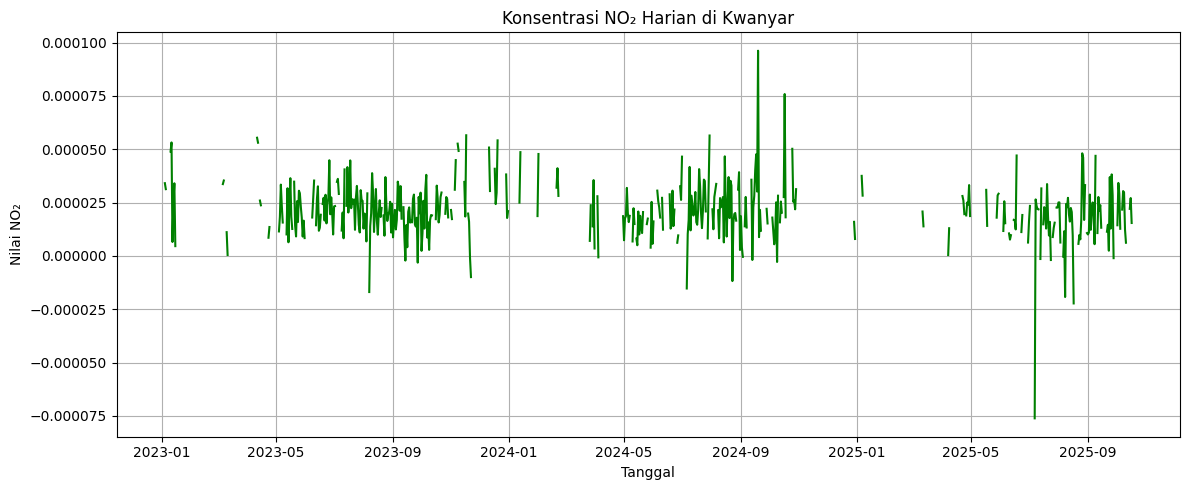

In [2]:
# --- 1. Instal & impor library ---
# (gunakan baris ini hanya jika environment baru, bisa dihapus kalau sudah terinstal)
# !pip install netCDF4 xarray pandas matplotlib

import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- 2. Tentukan lokasi file .nc hasil crawling ---
# Pastikan file 'openEO.nc' sudah ada di folder data/
data_path = "data/openEO.nc"

if not os.path.exists(data_path):
    raise FileNotFoundError(f"File {data_path} tidak ditemukan. Pastikan sudah ada di folder data/")

# --- 3. Baca file NetCDF (.nc) ---
ds = xr.open_dataset(data_path)
print("Dataset berhasil dibuka ✅")
print(ds)

# --- 4. Cek variabel yang tersedia ---
print("Variabel tersedia:", list(ds.data_vars))

# --- 5. Ambil nilai NO₂ dan waktu (rata-rata spasial) ---
no2_data = ds['NO2'].mean(dim=['x', 'y']).to_dataframe().reset_index()

# --- 6. Rapikan dataframe ---
no2_data = no2_data[['t', 'NO2']]
no2_data.rename(columns={'t': 'Tanggal'}, inplace=True)

# Pastikan kolom tanggal bertipe datetime
no2_data['Tanggal'] = pd.to_datetime(no2_data['Tanggal'])

# --- 7. Simpan ke file CSV ---
output_path = "data/NO2_Kwanyar.csv"
no2_data.to_csv(output_path, index=False)
print(f"✅ Data harian NO₂ disimpan ke: {output_path}")

# --- 8. Visualisasi sederhana ---
plt.figure(figsize=(12, 5))
plt.plot(no2_data['Tanggal'], no2_data['NO2'], color='green')
plt.title('Konsentrasi NO₂ Harian di Kwanyar')
plt.xlabel('Tanggal')
plt.ylabel('Nilai NO₂')
plt.grid(True)
plt.tight_layout()
plt.show()
